# Pixels to Predictions: DL Vision Challenge

**Student:** Siva Srinivas Venigalla  
**NetID:** sv2881  
**Model:** HuggingFaceTB/SmolVLM-500M-Instruct  
**Final Public Leaderboard Score:** 0.86317  

## Summary

This notebook presents the final reproducible training/inference pipeline for the Pixels to Predictions Kaggle competition. The task is multimodal scientific multiple-choice question answering. Each example contains an image, a question, answer choices, optional hint/lecture text, and metadata such as subject, topic, category, and skill.

The final solution uses SmolVLM-500M-Instruct with QLoRA adaptation. The model is loaded in 4-bit NF4 precision and fine-tuned using LoRA adapters under the trainable-parameter constraint. For inference, I do not rely on free-form generation. Instead, each candidate answer option is scored using normalized likelihood, and the most likely valid answer choice is selected.

The best final checkpoint was the cautious continued fine-tuning checkpoint from epoch 4, which achieved a public leaderboard score of 0.86317.

In [1]:
# ============================================================
# CELL 2: Environment Setup
# ============================================================
# This cell pins the working package versions used for SmolVLM.
# Important: do NOT downgrade transformers to 4.40.x.
# SmolVLM processor requires a newer Transformers version.

import os, sys, subprocess, textwrap
from pathlib import Path

def run(cmd):
    print("RUN:", cmd)
    subprocess.run(cmd, shell=True, check=True)

try:
    import transformers
    print("Current transformers:", transformers.__version__)
    assert transformers.__version__ == "4.57.1"
    import peft
    import bitsandbytes
    print("Environment already looks correct.")
except Exception as e:
    print("Environment needs fixing:", repr(e))
    run("pip uninstall -y transformers tokenizers accelerate peft bitsandbytes huggingface_hub -q")
    run(
        "pip install -q --no-cache-dir "
        "transformers==4.57.1 "
        "tokenizers==0.22.1 "
        "huggingface_hub==0.36.0 "
        "accelerate==1.11.0 "
        "peft==0.13.2 "
        "bitsandbytes "
        "datasets "
        "pillow "
        "tqdm "
        "matplotlib "
        "seaborn"
    )
    print("\nRuntime will restart now. After restart, rerun from Cell 2.\n")
    os.kill(os.getpid(), 9)

Current transformers: 4.57.1
Environment already looks correct.


## Reproducibility Notes

The final solution depends on a stable package environment. During development, one failure mode came from using an older Transformers version that could not instantiate the SmolVLM processor. The final notebook therefore pins a modern Transformers version and keeps `bitsandbytes` installed for 4-bit NF4 model loading.

This notebook does not retrain the model by default. It loads the final saved LoRA adapter from Google Drive and regenerates the final Kaggle submission. This makes the notebook easier to grade and reproduce.

In [2]:
# ============================================================
# CELL 4: Imports, Seeds, and Global Config
# ============================================================

import os, json, random, gc, time, shutil, zipfile
from pathlib import Path

import numpy as np
import pandas as pd
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

import matplotlib.pyplot as plt

import transformers
from transformers import AutoProcessor, BitsAndBytesConfig

try:
    from transformers import AutoModelForImageTextToText as AutoVLMModel
except Exception:
    from transformers import AutoModelForVision2Seq as AutoVLMModel

from peft import PeftModel

# ----------------------------
# Reproducibility
# ----------------------------
SEED = 777
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

# ----------------------------
# Model / data config
# ----------------------------
MODEL_ID = "HuggingFaceTB/SmolVLM-500M-Instruct"
CHOICE_LETTERS = "ABCDEFGHIJ"

IMG_SIZE = 384

# Final mode: this notebook loads final adapter and runs inference.
RUN_INFERENCE = True

# Final known public score from Kaggle.
FINAL_PUBLIC_SCORE = 0.86317

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

print("Transformers:", transformers.__version__)
print("Torch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Transformers: 4.57.1
Torch: 2.10.0+cu128
CUDA available: True
GPU: Tesla T4


In [3]:
# ============================================================
# CELL 5: Mount Drive and Locate Dataset / Checkpoints
# ============================================================

from google.colab import drive
drive.mount("/content/drive")

candidate_dirs = [
    Path("/content/drive/MyDrive/pixels-to-predictions"),
    Path("/content/drive/My Drive/pixels-to-predictions"),
    Path("/content/pixels-to-predictions"),
]

DATA_DIR = None

for c in candidate_dirs:
    if (c / "train.csv").exists() and (c / "val.csv").exists() and (c / "test.csv").exists():
        DATA_DIR = c
        break

if DATA_DIR is None:
    print("Searching for dataset folder under /content/drive ...")
    for root, dirs, files in os.walk("/content/drive"):
        rootp = Path(root)
        if "train.csv" in files and "val.csv" in files and "test.csv" in files:
            DATA_DIR = rootp
            break

assert DATA_DIR is not None, "Could not find dataset folder."

print("DATA_DIR:", DATA_DIR)

# Final run/checkpoint folders used during development.
possible_run_dirs = [
    DATA_DIR / "final_fixed_smolvlm_qora",
    DATA_DIR / "final_clean_smolvlm_lora",
    DATA_DIR / "fresh_lora_v0_safe_overnight",
]

RUN_DIR = None
for rd in possible_run_dirs:
    if rd.exists():
        RUN_DIR = rd
        break

if RUN_DIR is None:
    RUN_DIR = DATA_DIR / "final_fixed_smolvlm_qora"
    RUN_DIR.mkdir(parents=True, exist_ok=True)

print("RUN_DIR:", RUN_DIR)

# Locate final epoch-4 adapter.
EPOCH4_ADAPTER = None

for root, dirs, files in os.walk(str(DATA_DIR)):
    rootp = Path(root)
    if "adapter_config.json" in files and "epoch4" in str(rootp).lower():
        EPOCH4_ADAPTER = rootp
        break

# If only a zip exists, unzip it.
if EPOCH4_ADAPTER is None:
    zip_candidates = []
    for root, dirs, files in os.walk(str(DATA_DIR)):
        for f in files:
            if f.endswith(".zip") and "epoch4" in f.lower():
                zip_candidates.append(Path(root) / f)

    if len(zip_candidates) > 0:
        zip_path = zip_candidates[0]
        EPOCH4_ADAPTER = RUN_DIR / "adapter_epoch4_unzipped_for_clean_notebook"
        EPOCH4_ADAPTER.mkdir(parents=True, exist_ok=True)

        with zipfile.ZipFile(zip_path, "r") as z:
            z.extractall(EPOCH4_ADAPTER)

        print("Unzipped epoch-4 adapter:", zip_path)

assert EPOCH4_ADAPTER is not None, (
    "Could not locate epoch-4 adapter. Upload/unzip the final adapter folder first."
)

print("Final adapter:", EPOCH4_ADAPTER)

# Locate final submission if already present.
final_submission_candidates = []
for root, dirs, files in os.walk(str(DATA_DIR)):
    for f in files:
        if f.endswith(".csv") and ("epoch4" in f.lower() or "cautious" in f.lower()):
            final_submission_candidates.append(Path(root) / f)

print("\nPossible final submissions:")
for p in final_submission_candidates[:10]:
    print(" -", p)

Mounted at /content/drive
DATA_DIR: /content/drive/MyDrive/pixels-to-predictions
RUN_DIR: /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora
Final adapter: /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora/adapter_epoch4_cautious

Possible final submissions:
 - /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora/submission_epoch4_cautious.csv
 - /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora/submission_epoch5_partial500_from_epoch4.csv


## Dataset

The dataset contains multimodal multiple-choice science questions. Each example contains:

- `id`: unique example ID
- `image_path`: path to the associated image
- `question`: question text
- `choices`: JSON list of answer options
- `num_choices`: number of valid answer options
- `answer`: correct answer index for train/validation
- `hint`, `lecture`: optional supporting context
- metadata columns such as `task`, `grade`, `subject`, `topic`, `category`, and `skill`

For the final leaderboard submission, I train on both the training and validation splits because the hidden test labels are used for leaderboard scoring. The validation set was used during development for method selection and ablation reasoning.

In [4]:
# ============================================================
# CELL 7: Load Data and Sanity Checks
# ============================================================

train_df = pd.read_csv(DATA_DIR / "train.csv")
val_df = pd.read_csv(DATA_DIR / "val.csv")
test_df = pd.read_csv(DATA_DIR / "test.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")

for df in [train_df, val_df, test_df]:
    df["choices"] = df["choices"].apply(lambda x: json.loads(x) if isinstance(x, str) else x)

fit_df = pd.concat([train_df, val_df], ignore_index=True).reset_index(drop=True)

print("Train shape:", train_df.shape)
print("Val shape:", val_df.shape)
print("Fit shape train+val:", fit_df.shape)
print("Test shape:", test_df.shape)
print("Sample submission shape:", sample_sub.shape)

display(train_df.head(2))
display(test_df.head(2))

print("\nNumber of choices distribution, train:")
display(train_df["num_choices"].value_counts().sort_index())

print("\nNumber of choices distribution, test:")
display(test_df["num_choices"].value_counts().sort_index())

Train shape: (3109, 15)
Val shape: (1048, 15)
Fit shape train+val: (4157, 15)
Test shape: (1008, 13)
Sample submission shape: (1008, 2)


,id,image_path,question,choices,num_choices,answer,hint,lecture,solution,task,grade,subject,topic,category,skill
0,train_07667,images/train/train_07667.png,Why might putting each tadpole in its own pool...,[the male's tadpoles will be larger when they ...,3,2,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...
1,train_02628,images/train/train_02628.png,Why might forming strong social bonds with oth...,"[the female's offspring will live longer, the ...",3,0,Animals often behave in certain ways that can ...,Animals increase their reproductive success wh...,Look for the part of the passage that describe...,closed choice,grade8,natural science,literacy-in-science,Adaptations and natural selection,How can animal behaviors affect reproductive s...


,id,image_path,question,choices,num_choices,hint,lecture,task,grade,subject,topic,category,skill
0,test_01750,images/test/test_01750.png,"Based on clues in the text, why would farmers ...",[The cats were thought to be visiting goddesse...,4,Read the text about cats.\nCats are among the ...,"Informational texts include many facts, exampl...",closed choice,grade5,language science,reading-comprehension,Informational texts: level 1,Read passages about animals
1,test_00128,images/test/test_00128.png,What is the probability that an American curl ...,"[0/4, 2/4, 4/4, 3/4, 1/4]",5,"In a group of American curl cats, some individ...",Offspring genotypes: homozygous or heterozygou...,closed choice,grade8,natural science,biology,Genes to traits,Use Punnett squares to calculate probabilities...



Number of choices distribution, train:


,count
num_choices,
2,664
3,1552
4,783
5,110



Number of choices distribution, test:


,count
num_choices,
2,272
3,438
4,260
5,38


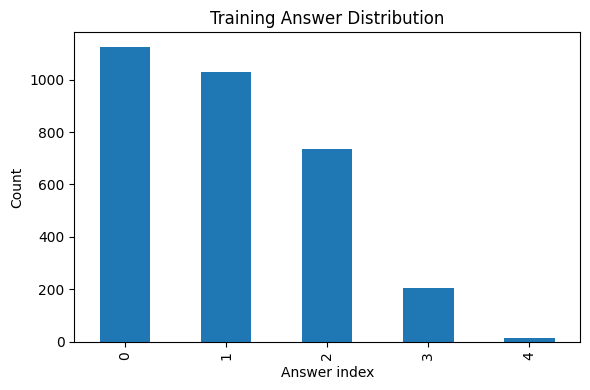

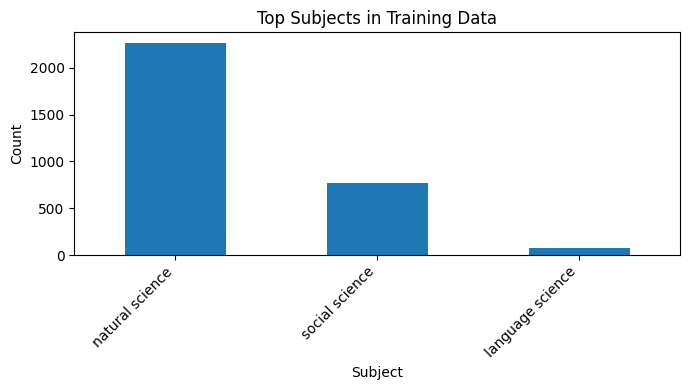

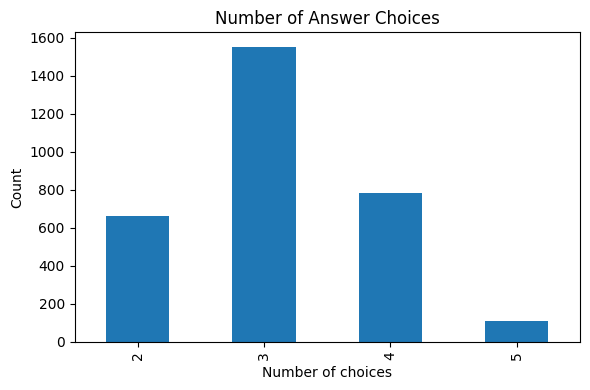

Saved report figures to: /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora/report_figures


In [5]:
# ============================================================
# CELL 8: Dataset Graphics for Report
# ============================================================

PLOT_DIR = RUN_DIR / "report_figures"
PLOT_DIR.mkdir(parents=True, exist_ok=True)

# Plot answer distribution in train/val.
fig = plt.figure(figsize=(6, 4))
train_df["answer"].value_counts().sort_index().plot(kind="bar")
plt.title("Training Answer Distribution")
plt.xlabel("Answer index")
plt.ylabel("Count")
plt.tight_layout()
answer_plot_path = PLOT_DIR / "answer_distribution_train.png"
plt.savefig(answer_plot_path, dpi=200)
plt.show()

# Plot subject distribution.
if "subject" in train_df.columns:
    fig = plt.figure(figsize=(7, 4))
    train_df["subject"].value_counts().head(10).plot(kind="bar")
    plt.title("Top Subjects in Training Data")
    plt.xlabel("Subject")
    plt.ylabel("Count")
    plt.xticks(rotation=45, ha="right")
    plt.tight_layout()
    subject_plot_path = PLOT_DIR / "subject_distribution_train.png"
    plt.savefig(subject_plot_path, dpi=200)
    plt.show()

# Plot number of choices.
fig = plt.figure(figsize=(6, 4))
train_df["num_choices"].value_counts().sort_index().plot(kind="bar")
plt.title("Number of Answer Choices")
plt.xlabel("Number of choices")
plt.ylabel("Count")
plt.tight_layout()
choices_plot_path = PLOT_DIR / "num_choices_distribution.png"
plt.savefig(choices_plot_path, dpi=200)
plt.show()

print("Saved report figures to:", PLOT_DIR)

## Prompt and Image Pipeline

Each example is converted into a compact multimodal prompt. The prompt starts with the `<image>` token, followed by short metadata, lesson/hint context, question, and answer choices. The model is trained and evaluated to output a single option letter.

A key implementation detail is that I manually shorten the `lecture` and `hint` fields before tokenization. I do not use processor-level truncation with image inputs during final inference, because truncation can create image-token mismatch errors for SmolVLM. Manual shortening preserves the image tokens while keeping memory use manageable.

Image size: (384, 384)

Prompt preview:

<image>
Answer this science multiple-choice question. Reply with only the option letter.

Grade: grade8
Subject: natural science
Topic: literacy-in-science
Category: Adaptations and natural selection
Skill: How can animal behaviors affect reproductive success? Identify evidence to support a claim

Lesson:
Animals increase their reproductive success when they have offspring that survive to reproduce.
Animals can increase their chances of having offspring by behaving in ways that help them get partners to mate and reproduce with. These partners are called mates. For example, animals may make special sounds, perform specific dances, or show off bright colors to attract mates. Animals may also compete with each other for mates.
Animals can increase the chances that their offspring will survive to reproduce by caring for and protecting them. For example, animals may feed their offspring or guard them from predators. These behaviors increase the chanc

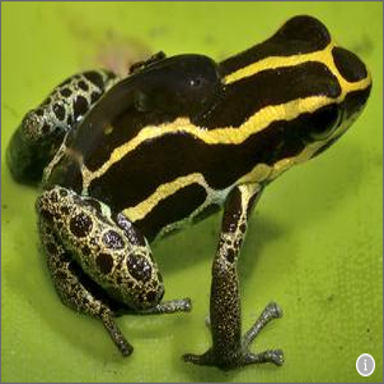

In [6]:
# ============================================================
# CELL 10: Image Loading and Prompt Formatting
# ============================================================

IMAGE_ROOTS = [
    DATA_DIR / "images" / "images",
    DATA_DIR / "images",
    DATA_DIR / "data" / "images",
    DATA_DIR / "data",
    DATA_DIR,
]

def sx(x):
    """Safe string conversion for optional dataset fields."""
    if pd.isna(x):
        return ""
    x = str(x).strip()
    if x.lower() in ["nan", "none", "null"]:
        return ""
    return x

def load_image(row):
    """
    Robust image loader.

    The dataset path layout changed slightly across local/Drive/Kaggle
    mirrors, so this function tries several valid path conventions.
    """
    rel = str(row["image_path"])
    fname = os.path.basename(rel)

    possible = [
        DATA_DIR / rel,
        DATA_DIR / "data" / rel,
        DATA_DIR / "images" / rel,
        DATA_DIR / "images" / "images" / rel.replace("images/", ""),
        DATA_DIR / "data" / "images" / rel.replace("images/", ""),
        DATA_DIR / "images" / "images" / "train" / fname,
        DATA_DIR / "images" / "images" / "val" / fname,
        DATA_DIR / "images" / "images" / "test" / fname,
    ]

    for root in IMAGE_ROOTS:
        possible += [
            root / rel,
            root / rel.replace("images/", ""),
            root / "train" / fname,
            root / "val" / fname,
            root / "test" / fname,
        ]

    for p in possible:
        if p.exists():
            img = Image.open(p).convert("RGB")
            img = img.resize((IMG_SIZE, IMG_SIZE), Image.BICUBIC)
            return img

    raise FileNotFoundError(f"Image not found: {rel}")

def build_prompt(row):
    """
    Final compact prompt.

    This is the prompt format used for the best checkpoint. It asks for
    a single option letter and includes shortened context.
    """
    q = sx(row.get("question", ""))
    lecture = sx(row.get("lecture", ""))
    hint = sx(row.get("hint", ""))

    subject = sx(row.get("subject", ""))
    topic = sx(row.get("topic", ""))
    category = sx(row.get("category", ""))
    skill = sx(row.get("skill", ""))
    grade = sx(row.get("grade", ""))

    choices = row["choices"]
    choices_str = "\n".join(
        f"{CHOICE_LETTERS[i]}. {str(choices[i])}"
        for i in range(len(choices))
    )

    prompt = "<image>\n"
    prompt += "Answer this science multiple-choice question. Reply with only the option letter.\n\n"

    if subject or topic or category or skill or grade:
        prompt += f"Grade: {grade}\n"
        prompt += f"Subject: {subject}\n"
        prompt += f"Topic: {topic}\n"
        prompt += f"Category: {category}\n"
        prompt += f"Skill: {skill}\n\n"

    if lecture:
        prompt += f"Lesson:\n{lecture[:1200]}\n\n"

    if hint:
        prompt += f"Hint:\n{hint[:700]}\n\n"

    prompt += f"Question:\n{q}\n\n"
    prompt += f"Choices:\n{choices_str}\n\n"
    prompt += "Answer:"

    return prompt

# Sanity check
sample_row = train_df.iloc[0]
sample_img = load_image(sample_row)

print("Image size:", sample_img.size)
print("\nPrompt preview:\n")
print(build_prompt(sample_row)[:1000])

display(sample_img)

## Model

The final model is `HuggingFaceTB/SmolVLM-500M-Instruct`. I chose this model because the contest specifically centers on SmolVLM-style multimodal reasoning, and the model is small enough to adapt under free-tier GPU constraints.

The final adaptation setup uses:

- 4-bit NF4 quantized loading with bitsandbytes
- LoRA rank `r = 8`
- LoRA alpha `16`
- LoRA dropout `0.05`
- Target modules: `q_proj`, `k_proj`, `v_proj`, `o_proj`, `gate_proj`, `up_proj`, `down_proj`
- Approximately 4.78M trainable parameters

This keeps the model below the trainable-parameter limit while still adapting the language reasoning layers.

In [7]:
# ============================================================
# CELL 12: Load Final Epoch-4 Adapter
# ============================================================

processor = AutoProcessor.from_pretrained(MODEL_ID)

if processor.tokenizer.pad_token is None:
    processor.tokenizer.pad_token = processor.tokenizer.eos_token

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

base_model = AutoVLMModel.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    low_cpu_mem_usage=True,
)

model = PeftModel.from_pretrained(
    base_model,
    EPOCH4_ADAPTER,
    is_trainable=False,
)

model.eval()
model.config.use_cache = False

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())

print("Loaded final adapter:", EPOCH4_ADAPTER)
print("Trainable params during inference:", trainable)
print("Total params:", total)

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


processor_config.json:   0%|          | 0.00/68.0 [00:00<?, ?B/s]

chat_template.json:   0%|          | 0.00/429 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/486 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

...

special_tokens_map.json: 0.00B [00:00, ?B/s]

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/1.02G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/136 [00:00<?, ?B/s]

Loaded final adapter: /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora/adapter_epoch4_cautious
Trainable params during inference: 0
Total params: 306614464


## Inference Method: Likelihood Scoring

Instead of asking the model to freely generate an answer, I score every valid candidate answer choice.

For a question with `n` choices, I create `n` candidate strings by appending `A`, `B`, `C`, ... to the same prompt. The model computes the average negative token loss for each candidate answer. The candidate with the highest likelihood score is selected as the final prediction.

This is more stable than generation because:

1. The output space is restricted to valid answer choices.
2. It avoids invalid generated text.
3. It works well for variable numbers of answer choices.
4. It gives deterministic predictions with `model.eval()` and `torch.no_grad()`.

In [8]:
# ============================================================
# CELL 14: Multiple-Choice Likelihood Scoring
# ============================================================

@torch.no_grad()
def score_row(row):
    """
    Score every answer choice by average negative token loss.

    Higher score = more likely answer.
    """
    prompt = build_prompt(row)
    n = int(row["num_choices"])
    img = load_image(row)

    texts = [prompt + " " + CHOICE_LETTERS[i] for i in range(n)]
    images = [img] * n

    # Important: no processor truncation with SmolVLM image tokens.
    enc = processor(
        text=texts,
        images=images,
        return_tensors="pt",
        padding=True,
        truncation=False,
    ).to(model.device)

    prompt_enc = processor(
        text=[prompt],
        images=[img],
        return_tensors="pt",
        padding=True,
        truncation=False,
    ).to(model.device)

    prompt_len = int(prompt_enc["attention_mask"][0].sum().item())

    out = model(**enc)
    logits = out.logits
    input_ids = enc["input_ids"]
    attn = enc["attention_mask"]

    shift_logits = logits[:, :-1, :].contiguous()
    shift_labels = input_ids[:, 1:].contiguous()
    shift_attn = attn[:, 1:].contiguous()

    mask = torch.zeros_like(shift_labels, dtype=torch.bool)
    mask[:, prompt_len - 1:] = True
    mask = mask & shift_attn.bool()

    pad_id = processor.tokenizer.pad_token_id
    if pad_id is not None:
        mask = mask & (shift_labels != pad_id)

    losses = F.cross_entropy(
        shift_logits.reshape(-1, shift_logits.shape[-1]),
        shift_labels.reshape(-1),
        reduction="none",
    ).reshape(shift_labels.shape)

    scores = []
    for i in range(n):
        m = mask[i]
        if m.sum().item() == 0:
            scores.append(-1e9)
        else:
            scores.append(-losses[i][m].mean().item())

    return np.array(scores, dtype=np.float32)

def predict_row(row):
    scores = score_row(row)
    return int(np.argmax(scores))

# Quick sanity test on one validation example
val_example = val_df.iloc[0]
scores = score_row(val_example)
print("Scores:", scores)
print("Prediction:", int(np.argmax(scores)))
print("Ground truth:", int(val_example["answer"]))

Scores: [-2.09927559e-04 -1.27890625e+01 -1.46562500e+01]
Prediction: 0
Ground truth: 0


In [9]:
# ============================================================
# CELL 15: Generate Final Submission
# ============================================================

FINAL_SUBMISSION_PATH = RUN_DIR / "submission_final_epoch4_086317.csv"

if RUN_INFERENCE:
    preds = []

    for _, row in tqdm(test_df.iterrows(), total=len(test_df), desc="Final epoch-4 inference"):
        preds.append(predict_row(row))

    submission = pd.DataFrame({
        "id": test_df["id"].values,
        "answer": preds,
    })

    submission = sample_sub[["id"]].merge(submission, on="id", how="left")
    assert submission["answer"].isna().sum() == 0

    submission["answer"] = submission["answer"].astype(int)

    # Validate answer ranges.
    if "num_choices" in test_df.columns:
        id_to_n = dict(zip(test_df["id"], test_df["num_choices"]))
        bad = []
        for _, r in submission.iterrows():
            ans = int(r["answer"])
            n = int(id_to_n[r["id"]])
            if ans < 0 or ans >= n:
                bad.append((r["id"], ans, n))
        assert len(bad) == 0, f"Invalid predictions: {bad[:5]}"

    submission.to_csv(FINAL_SUBMISSION_PATH, index=False)

else:
    assert FINAL_SUBMISSION_PATH.exists(), "No final submission found and RUN_INFERENCE=False."
    submission = pd.read_csv(FINAL_SUBMISSION_PATH)

print("Saved final submission:", FINAL_SUBMISSION_PATH)
print("Shape:", submission.shape)
display(submission.head())
display(submission["answer"].value_counts().sort_index())

try:
    from google.colab import files
    files.download(str(FINAL_SUBMISSION_PATH))
except Exception as e:
    print("Manual download from:", FINAL_SUBMISSION_PATH)
    print(e)

Final epoch-4 inference:   0%|          | 0/1008 [00:00<?, ?it/s]

Saved final submission: /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora/submission_final_epoch4_086317.csv
Shape: (1008, 2)


,id,answer
0,test_01750,2
1,test_00128,0
2,test_02891,0
3,test_02425,1
4,test_00930,2


,count
answer,
0,359
1,368
2,207
3,71
4,3


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Experiments and Ablations

The main development process involved several controlled changes:

1. Frozen SmolVLM with likelihood scoring.
2. QLoRA fine-tuning with LoRA rank 8.
3. Continued training from saved adapters.
4. Fixing PEFT reload gradients by disabling gradient checkpointing.
5. Manual prompt shortening instead of processor truncation.
6. Cautious continued training with smaller learning rates.
7. Prompt ensemble and text-only fallback attempts, which did not improve the final score.

The best result came from continued QLoRA fine-tuning through epoch 4 with likelihood-based inference.

,experiment,description,public_score,what_changed,observation
0,Frozen SmolVLM baseline,No fine-tuning; likelihood scoring only,0.58551,Base model only,Good baseline but weak adaptation to contest f...
1,QLoRA epoch 2,4-bit SmolVLM + LoRA r=8; train+val,0.80080,Supervised LoRA adaptation,Large gain from task-specific fine-tuning
2,Continued epoch 3,"Reload adapter, fix gradient issue, continue t...",0.85510,Stable continued fine-tuning,Major improvement after fixing training stability
3,Cautious epoch 4,Lower-LR continued training,0.86317,Smaller LR continuation,Best final result
4,Epoch 5 partial,Extra low-LR partial fine-tuning,0.86317,Additional small update,No measurable leaderboard improvement
5,Prompt ensemble / text fallback,Prompt variants and TF-IDF fallback,NaN,Inference-time blending,Weaker prompt variants reduced validation perf...


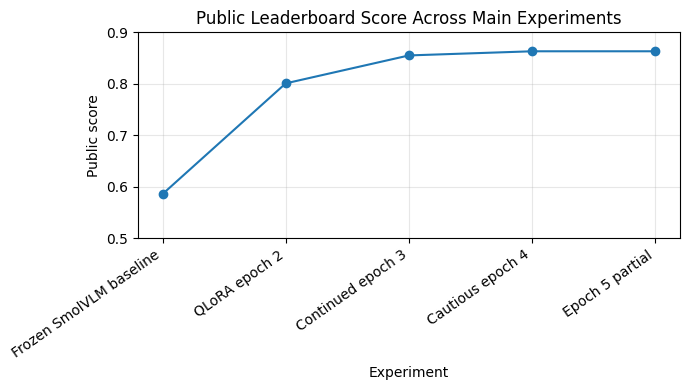

Saved ablation CSV: /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora/ablation_results.csv
Saved score trend plot: /content/drive/MyDrive/pixels-to-predictions/final_fixed_smolvlm_qora/report_figures/public_score_trend.png


In [10]:
# ============================================================
# CELL 17: Ablation Table and Result Plots
# ============================================================

ablation_rows = [
    {
        "experiment": "Frozen SmolVLM baseline",
        "description": "No fine-tuning; likelihood scoring only",
        "public_score": 0.58551,
        "what_changed": "Base model only",
        "observation": "Good baseline but weak adaptation to contest format",
    },
    {
        "experiment": "QLoRA epoch 2",
        "description": "4-bit SmolVLM + LoRA r=8; train+val",
        "public_score": 0.80080,
        "what_changed": "Supervised LoRA adaptation",
        "observation": "Large gain from task-specific fine-tuning",
    },
    {
        "experiment": "Continued epoch 3",
        "description": "Reload adapter, fix gradient issue, continue training",
        "public_score": 0.85510,
        "what_changed": "Stable continued fine-tuning",
        "observation": "Major improvement after fixing training stability",
    },
    {
        "experiment": "Cautious epoch 4",
        "description": "Lower-LR continued training",
        "public_score": 0.86317,
        "what_changed": "Smaller LR continuation",
        "observation": "Best final result",
    },
    {
        "experiment": "Epoch 5 partial",
        "description": "Extra low-LR partial fine-tuning",
        "public_score": 0.86317,
        "what_changed": "Additional small update",
        "observation": "No measurable leaderboard improvement",
    },
    {
        "experiment": "Prompt ensemble / text fallback",
        "description": "Prompt variants and TF-IDF fallback",
        "public_score": np.nan,
        "what_changed": "Inference-time blending",
        "observation": "Weaker prompt variants reduced validation performance",
    },
]

ablation_df = pd.DataFrame(ablation_rows)
ablation_path = RUN_DIR / "ablation_results.csv"
ablation_df.to_csv(ablation_path, index=False)

display(ablation_df)

# Plot public score trend for successful checkpoint path.
score_trend = ablation_df.dropna(subset=["public_score"]).copy()

fig = plt.figure(figsize=(7, 4))
plt.plot(score_trend["experiment"], score_trend["public_score"], marker="o")
plt.title("Public Leaderboard Score Across Main Experiments")
plt.xlabel("Experiment")
plt.ylabel("Public score")
plt.xticks(rotation=35, ha="right")
plt.ylim(0.50, 0.90)
plt.grid(True, alpha=0.3)
plt.tight_layout()

score_plot_path = PLOT_DIR / "public_score_trend.png"
plt.savefig(score_plot_path, dpi=200)
plt.show()

print("Saved ablation CSV:", ablation_path)
print("Saved score trend plot:", score_plot_path)

## Error Analysis and Limitations

The main engineering issues were:

1. **Package mismatch:** Older Transformers versions did not recognize the SmolVLM processor. This was fixed by pinning a modern Transformers version.
2. **Image-token truncation:** Processor-level truncation caused image-token mismatch errors. This was fixed by manually shortening text and disabling processor truncation for image inputs.
3. **Runtime instability:** Colab runtime disconnects sometimes removed models from memory. This was handled by saving adapters after each important checkpoint.
4. **Gradient issue after PEFT reload:** Reloaded LoRA adapters sometimes produced a loss without gradient. Disabling gradient checkpointing and explicitly enabling LoRA parameters fixed this issue.
5. **Prompt ensemble weakness:** Averaging strong and weak prompt variants degraded performance, so the final submission uses only the best prompt/inference path.

Remaining model limitations include difficulty with fine-grained diagrams, spatial reasoning, and questions requiring very long scientific context. Additional gains may require multi-seed ensembles, better validation-driven checkpoint selection, or larger allowed models.

In [11]:
# ============================================================
# CELL 19: Generate Report-Ready Text Snippets
# ============================================================

report_snippet = f"""
# Report Snippets

## Final Model
The final system uses HuggingFaceTB/SmolVLM-500M-Instruct with QLoRA adaptation.
The base model is loaded in 4-bit NF4 precision, and only LoRA adapter parameters are trained.
The LoRA configuration uses rank 8, alpha 16, dropout 0.05, and targets q_proj, k_proj,
v_proj, o_proj, gate_proj, up_proj, and down_proj. This keeps trainable parameters below
the 5M project constraint.

## Final Inference
For inference, I score each answer option using likelihood instead of free-form generation.
For every question, the same prompt is paired with each candidate option letter. The option
with the highest average likelihood is selected. This avoids invalid generations and gives
deterministic predictions.

## Final Result
The best final public leaderboard score is {FINAL_PUBLIC_SCORE:.5f}, obtained by the epoch-4
continued QLoRA checkpoint.

## AI Tooling Disclosure
I used ChatGPT as a coding and debugging assistant for package compatibility issues,
Colab runtime recovery, LoRA checkpoint loading, and report organization. All model training,
inference, and leaderboard submissions used only the provided Kaggle competition data.
No external training data was used.
"""

snippet_path = RUN_DIR / "report_snippets.md"
with open(snippet_path, "w") as f:
    f.write(report_snippet)

print(report_snippet)
print("Saved report snippets:", snippet_path)


# Report Snippets

## Final Model
The final system uses HuggingFaceTB/SmolVLM-500M-Instruct with QLoRA adaptation.
The base model is loaded in 4-bit NF4 precision, and only LoRA adapter parameters are trained.
The LoRA configuration uses rank 8, alpha 16, dropout 0.05, and targets q_proj, k_proj,
v_proj, o_proj, gate_proj, up_proj, and down_proj. This keeps trainable parameters below
the 5M project constraint.

## Final Inference
For inference, I score each answer option using likelihood instead of free-form generation.
For every question, the same prompt is paired with each candidate option letter. The option
with the highest average likelihood is selected. This avoids invalid generations and gives
deterministic predictions.

## Final Result
The best final public leaderboard score is 0.86317, obtained by the epoch-4
continued QLoRA checkpoint.

## AI Tooling Disclosure
I used ChatGPT as a coding and debugging assistant for package compatibility issues,
Colab runtime recovery, LoRA ch